In [1]:
import sys
import pyspark

print("Python:", sys.executable)
print("PySpark:", pyspark.__version__)

Python: /Users/Sid/Documents/FinalProject-CS675/code-starter/.venv/bin/python3
PySpark: 3.5.8


# Step 1: Start the Spark Session

In [50]:
import os

os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"

from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("Financial Fraud Analysis")
    .master("local[*]")
    .config("spark.driver.host", "127.0.0.1")
    .config("spark.driver.bindAddress", "127.0.0.1")
    .getOrCreate()
)

print("Spark Version:", spark.version)
print("Spark session started successfully!")

Spark Version: 3.5.8
Spark session started successfully!


26/08/01 11:52:07 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


# Step 2: Verify Dataset Paths

In [51]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nDatasets folder contents:")
print(os.listdir("../datasets"))

Current working directory:
/Users/Sid/Documents/FinalProject-CS675/code-starter/CS675_Financial_Fraud_Project/notebooks

Datasets folder contents:
['2025_Gaz_zcta_national.txt', 'credit_card_transactions-ibm_v2.csv', '.ipynb_checkpoints']


# Phase 1: Data Understanding

# 1. Import Libraries

In [4]:
import os

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import (
    StringType,
    IntegerType,
    DoubleType
)

# 2. Create the Spark Session

In [5]:
os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"

spark = (
    SparkSession.builder
    .appName("Geospatial Financial Fraud Analytics")
    .master("local[*]")
    .config("spark.driver.host", "127.0.0.1")
    .config("spark.driver.bindAddress", "127.0.0.1")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

print("Spark version:", spark.version)
print("Spark session started successfully.")

Spark version: 3.5.8
Spark session started successfully.


26/08/01 10:31:20 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


# 3. Define Dataset Paths

In [6]:
DATASET_FOLDER = "../datasets"

TRANSACTIONS_PATH = (
    f"{DATASET_FOLDER}/credit_card_transactions-ibm_v2.csv"
)

ZCTA_PATH = (
    f"{DATASET_FOLDER}/2025_Gaz_zcta_national.txt"
)

print("Transaction dataset:", TRANSACTIONS_PATH)
print("Census dataset:", ZCTA_PATH)

Transaction dataset: ../datasets/credit_card_transactions-ibm_v2.csv
Census dataset: ../datasets/2025_Gaz_zcta_national.txt


# 4. Verify the Dataset Files

In [7]:
print("Current working directory:")
print(os.getcwd())

print("\nFiles in the datasets folder:")
for file_name in os.listdir(DATASET_FOLDER):
    print(file_name)

Current working directory:
/Users/Sid/Documents/FinalProject-CS675/code-starter/CS675_Financial_Fraud_Project/notebooks

Files in the datasets folder:
2025_Gaz_zcta_national.txt
credit_card_transactions-ibm_v2.csv
.ipynb_checkpoints


# 5. Load the IBM Credit Card Transactions Dataset

In [8]:
transactions_df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .option("mode", "PERMISSIVE")
    .csv(TRANSACTIONS_PATH)
)

print("IBM transaction dataset loaded successfully.")

[Stage 1:=====================================================>   (17 + 1) / 18]

IBM transaction dataset loaded successfully.


# 6. Inspect the Transaction Dataset

In [9]:
# Schema
transactions_df.printSchema()

# Column Names
print("Number of columns:", len(transactions_df.columns))

print("\nColumn names:")
for column_name in transactions_df.columns:
    print(column_name)

# Frist five records
transactions_df.show(5, truncate=False)

# Number of Rows
transaction_count = transactions_df.count()

print(f"Total transaction records: {transaction_count:,}")

root
 |-- User: integer (nullable = true)
 |-- Card: integer (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Month: integer (nullable = true)
 |-- Day: integer (nullable = true)
 |-- Time: timestamp (nullable = true)
 |-- Amount: string (nullable = true)
 |-- Use Chip: string (nullable = true)
 |-- Merchant Name: long (nullable = true)
 |-- Merchant City: string (nullable = true)
 |-- Merchant State: string (nullable = true)
 |-- Zip: double (nullable = true)
 |-- MCC: integer (nullable = true)
 |-- Errors?: string (nullable = true)
 |-- Is Fraud?: string (nullable = true)

Number of columns: 15

Column names:
User
Card
Year
Month
Day
Time
Amount
Use Chip
Merchant Name
Merchant City
Merchant State
Zip
MCC
Errors?
Is Fraud?
+----+----+----+-----+---+-------------------+-------+-----------------+-------------------+-------------+--------------+-------+----+-------+---------+
|User|Card|Year|Month|Day|Time               |Amount |Use Chip         |Merchant Name      |Merchant C

[Stage 3:=====================================================>   (17 + 1) / 18]

Total transaction records: 24,386,900


# 7. Load the Census ZCTA Dataset

In [10]:
zcta_df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .option("sep", "|")
    .option("mode", "PERMISSIVE")
    .csv(ZCTA_PATH)
)

print("Census ZCTA dataset loaded successfully.")

Census ZCTA dataset loaded successfully.


# 8. Inspect the Census Dataset

In [11]:
# Schema

zcta_df.printSchema()

# Column names

print("Number of columns:", len(zcta_df.columns))

print("\nColumn names:")
for column_name in zcta_df.columns:
    print(column_name)


# First five records
zcta_df.show(5, truncate=False)

# Number of rows
zcta_count = zcta_df.count()

print(f"Total Census ZCTA records: {zcta_count:,}")



root
 |-- GEOID: integer (nullable = true)
 |-- GEOIDFQ: string (nullable = true)
 |-- ALAND: long (nullable = true)
 |-- AWATER: long (nullable = true)
 |-- ALAND_SQMI: double (nullable = true)
 |-- AWATER_SQMI: double (nullable = true)
 |-- INTPTLAT: double (nullable = true)
 |-- INTPTLONG: double (nullable = true)

Number of columns: 8

Column names:
GEOID
GEOIDFQ
ALAND
AWATER
ALAND_SQMI
AWATER_SQMI
INTPTLAT
INTPTLONG
+-----+--------------+---------+-------+----------+-----------+---------+----------+
|GEOID|GEOIDFQ       |ALAND    |AWATER |ALAND_SQMI|AWATER_SQMI|INTPTLAT |INTPTLONG |
+-----+--------------+---------+-------+----------+-----------+---------+----------+
|601  |860Z200US00601|166836450|798613 |64.416    |0.308      |18.180555|-66.749961|
|602  |860Z200US00602|78546196 |4428428|30.327    |1.71       |18.361945|-67.175597|
|603  |860Z200US00603|88980553 |6253316|34.356    |2.414      |18.457399|-67.124867|
|606  |860Z200US00606|114825645|12228  |44.334    |0.005      |18

# 9. Inspect the Join Columns
We are joining Transaction Zip → Census GEOID

In [12]:
# IBM ZIP Values
transactions_df.select("Zip").show(20, truncate=False)

# Census ZIP Values
zcta_df.select(
    "GEOID",
    "INTPTLAT",
    "INTPTLONG"
).show(20, truncate=False)

+-------+
|Zip    |
+-------+
|91750.0|
|91754.0|
|91754.0|
|91754.0|
|91750.0|
|91755.0|
|91754.0|
|91754.0|
|91754.0|
|91750.0|
|91750.0|
|NULL   |
|91752.0|
|91754.0|
|91755.0|
|91750.0|
|91750.0|
|91750.0|
|91754.0|
|91752.0|
+-------+
only showing top 20 rows

+-----+---------+----------+
|GEOID|INTPTLAT |INTPTLONG |
+-----+---------+----------+
|601  |18.180555|-66.749961|
|602  |18.361945|-67.175597|
|603  |18.457399|-67.124867|
|606  |18.15832 |-66.932928|
|610  |18.295304|-67.12518 |
|611  |18.276316|-66.807165|
|612  |18.416727|-66.70009 |
|616  |18.420408|-66.671986|
|617  |18.446889|-66.561154|
|622  |17.988103|-67.160357|
|623  |18.084371|-67.158765|
|624  |18.051808|-66.721711|
|627  |18.412423|-66.863708|
|631  |18.184294|-66.830795|
|636  |18.1636  |-67.080097|
|637  |18.080103|-66.947975|
|638  |18.280188|-66.513111|
|641  |18.268074|-66.701785|
|646  |18.432897|-66.286499|
|647  |17.963613|-66.947127|
+-----+---------+----------+
only showing top 20 rows



### Insights:

The join columns from both datasets were inspected before performing the data integration.

The IBM transaction dataset contains a `Zip` column representing the ZIP Code associated with each transaction. The sample output shows that ZIP Codes are currently stored as decimal values (for example, `91750.0`) and that some records contain `NULL` values.

The Census ZCTA dataset contains the `GEOID` column, which represents ZIP Code Tabulation Areas (ZCTAs). It also includes the geographic coordinates (`INTPTLAT` and `INTPTLONG`) that will later be used for geospatial analysis.

From the sample output, it is clear that both datasets contain ZIP Code information, but the formatting is different. The transaction dataset stores ZIP Codes as decimal numbers, while the Census dataset stores them as integer values without decimal places.

Before joining the datasets, the ZIP Code fields will be cleaned and converted into the same format. Records with missing ZIP Codes will also be handled appropriately to improve the accuracy of the data integration.

In [13]:
# Checking the datatype
print(
    "Transaction Zip data type:",
    transactions_df.schema["Zip"].dataType
)

print(
    "Census GEOID data type:",
    zcta_df.schema["GEOID"].dataType
)

Transaction Zip data type: DoubleType()
Census GEOID data type: IntegerType()


### Insights:

The data types of the join columns were examined to verify whether the datasets are ready for integration.

The `Zip` column in the IBM transaction dataset is stored as a **DoubleType**, meaning ZIP Codes are represented as decimal values such as `91750.0`.

The `GEOID` column in the Census ZCTA dataset is stored as an **IntegerType**, meaning ZIP Codes are represented as whole numbers without decimal places.

Because the join columns have different data types, they cannot be matched reliably in their current form. Before performing the join, both columns will be cleaned and converted to a common format. This preprocessing step is essential to ensure accurate matching between transaction records and the corresponding geographic information from the Census dataset.

# 10. Review Fraud Distribution

In [14]:
transactions_df.groupBy("Is Fraud?") \
    .count() \
    .orderBy(F.desc("count")) \
    .show()

[Stage 14:====================================================>   (17 + 1) / 18]

+---------+--------+
|Is Fraud?|   count|
+---------+--------+
|       No|24357143|
|      Yes|   29757|
+---------+--------+



### Fraud Data Insights:

The fraud distribution was examined to understand the proportion of fraudulent and legitimate transactions within the dataset.

The results show that the dataset contains **24,357,143** legitimate transactions and **29,757** fraudulent transactions. This indicates that fraudulent transactions represent only a very small percentage of the overall data.

This type of class imbalance is common in real-world financial transaction data, where fraud occurs infrequently compared to normal customer activity. Understanding this distribution is important because it provides context for the analysis and highlights the challenge of detecting fraudulent behavior within a very large volume of legitimate transactions.

In the later stages of this project, the fraud records will be analyzed by geographic location, transaction characteristics, and payment behavior to identify patterns and potential fraud hotspots.

In [15]:
# Calculate the Fraud Percentage

fraud_summary_df = (
    transactions_df
    .groupBy("Is Fraud?")
    .count()
    .withColumn(
        "percentage",
        F.round(
            F.col("count") / F.lit(transaction_count) * 100,
            4
        )
    )
)

fraud_summary_df.show()

[Stage 17:====================================================>   (17 + 1) / 18]

+---------+--------+----------+
|Is Fraud?|   count|percentage|
+---------+--------+----------+
|       No|24357143|    99.878|
|      Yes|   29757|     0.122|
+---------+--------+----------+



### Insights on Fraud Percentage:

The fraud distribution was analyzed to understand the proportion of fraudulent and legitimate transactions within the dataset.

The analysis shows that the dataset contains **24,357,143 legitimate transactions (99.8780%)** and **29,757 fraudulent transactions (0.1220%)**. This demonstrates that fraudulent transactions represent only a very small fraction of the total transaction volume.

This highly imbalanced distribution is typical of real-world financial transaction data, where the vast majority of transactions are legitimate. Understanding this imbalance is important because it highlights the difficulty of detecting fraudulent activity within millions of normal transactions.

Although this project focuses on large-scale fraud analytics rather than machine learning, identifying this imbalance provides valuable business insight and establishes a foundation for further analysis. In the next stages, fraud transactions will be examined by geographic location, merchant characteristics, payment method, and transaction attributes to identify fraud patterns and regional hotspots.

# 11. Check Missing Values in Important Columns

In [16]:
important_columns = [
    "Amount",
    "Use Chip",
    "Merchant State",
    "Zip",
    "MCC",
    "Is Fraud?"
]

missing_values_df = transactions_df.select([
    F.sum(
        F.when(
            F.col(column_name).isNull() |
            (F.trim(F.col(column_name).cast("string")) == ""),
            1
        ).otherwise(0)
    ).alias(column_name)
    for column_name in important_columns
])

missing_values_df.show(truncate=False)

[Stage 20:====================================================>   (17 + 1) / 18]

+------+--------+--------------+-------+---+---------+
|Amount|Use Chip|Merchant State|Zip    |MCC|Is Fraud?|
+------+--------+--------------+-------+---+---------+
|0     |0       |2720821       |2878135|0  |0        |
+------+--------+--------------+-------+---+---------+



### Missing Values Insights:

The missing values in the IBM transaction dataset were examined to identify any data quality issues before analysis and data integration.

The results show that the `Amount`, `Use Chip`, `MCC`, and `Is Fraud?` columns do not contain any missing values, indicating that these key analytical fields are complete.

However, missing values were identified in the `Merchant State` column (**2,720,821 records**) and the `Zip` column (**2,878,135 records**). Since the ZIP Code is required to join the transaction data with the Census geographic dataset, these missing values must be considered during the data preparation phase. Transactions without ZIP Codes cannot be matched to geographic information and may need to be excluded from geospatial analyses.

Overall, the dataset has good data quality for the primary analytical variables, with missing values mainly limited to geographic attributes.

In [17]:
# For the census data

zcta_missing_df = zcta_df.select([
    F.sum(
        F.when(
            F.col(column_name).isNull() |
            (F.trim(F.col(column_name).cast("string")) == ""),
            1
        ).otherwise(0)
    ).alias(column_name)
    for column_name in [
        "GEOID",
        "INTPTLAT",
        "INTPTLONG"
    ]
])

zcta_missing_df.show(truncate=False)

+-----+--------+---------+
|GEOID|INTPTLAT|INTPTLONG|
+-----+--------+---------+
|0    |0       |0        |
+-----+--------+---------+



### Insights:

The Census ZCTA dataset was also examined for missing values to ensure it is suitable for geographic data integration.

The results show that the `GEOID`, `INTPTLAT`, and `INTPTLONG` columns contain **no missing values**. This indicates that every ZIP Code Tabulation Area has complete geographic information, including its corresponding latitude and longitude.

Because the Census dataset is complete for these key fields, it provides a reliable geographic reference that can be joined with the transaction dataset after the ZIP Code formats are standardized.

# Phase 2: Data Cleaning and Preparation

## 12.1 Clean the Transaction Amount

The Amount column is currently stored as a string because it contains the $ symbol. We'll remove the symbol and convert the values to a numeric type.

In [18]:
transactions_df = transactions_df.withColumn(
    "Amount",
    F.regexp_replace("Amount", "\\$", "").cast("double")
)

print("Amount column cleaned successfully.")

Amount column cleaned successfully.


In [19]:
transactions_df.select("Amount").show(10, truncate=False)

+------+
|Amount|
+------+
|134.09|
|38.48 |
|120.34|
|128.95|
|104.71|
|86.19 |
|93.84 |
|123.5 |
|61.72 |
|57.1  |
+------+
only showing top 10 rows



In [20]:
transactions_df.printSchema()

root
 |-- User: integer (nullable = true)
 |-- Card: integer (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Month: integer (nullable = true)
 |-- Day: integer (nullable = true)
 |-- Time: timestamp (nullable = true)
 |-- Amount: double (nullable = true)
 |-- Use Chip: string (nullable = true)
 |-- Merchant Name: long (nullable = true)
 |-- Merchant City: string (nullable = true)
 |-- Merchant State: string (nullable = true)
 |-- Zip: double (nullable = true)
 |-- MCC: integer (nullable = true)
 |-- Errors?: string (nullable = true)
 |-- Is Fraud?: string (nullable = true)



### Explanation

The `Amount` column was successfully cleaned by removing the dollar (`$`) symbol and converting the values from text to the `DoubleType` data type.

This transformation is necessary because Spark cannot perform mathematical operations on string values. After cleaning, transaction amounts can now be used for statistical analysis, aggregation, filtering, and visualization throughout the project.

## 12.2 Clean the ZIP Code

In [21]:
transactions_df = transactions_df.withColumn(
    "Zip",
    F.col("Zip").cast("int").cast("string")
)

transactions_df.select("Zip").show(20, truncate=False)

+-----+
|Zip  |
+-----+
|91750|
|91754|
|91754|
|91754|
|91750|
|91755|
|91754|
|91754|
|91754|
|91750|
|91750|
|NULL |
|91752|
|91754|
|91755|
|91750|
|91750|
|91750|
|91754|
|91752|
+-----+
only showing top 20 rows



### Standardizing ZIP Codes

The ZIP Code field in the transaction dataset is stored as a decimal value. Since ZIP Codes are identifiers rather than numerical measurements, the values are converted to integer format and then to strings. Standardizing the ZIP Code format ensures compatibility with the Census dataset during the data integration process.

## 12.3 Clean the Census ZIP Codes

The Census GEOID column is already an integer, but we'll convert it to a string so both datasets use the same type.

In [22]:
zcta_df = zcta_df.withColumn(
    "GEOID",
    F.col("GEOID").cast("string")
)

zcta_df.select("GEOID").show(20, truncate=False)

+-----+
|GEOID|
+-----+
|601  |
|602  |
|603  |
|606  |
|610  |
|611  |
|612  |
|616  |
|617  |
|622  |
|623  |
|624  |
|627  |
|631  |
|636  |
|637  |
|638  |
|641  |
|646  |
|647  |
+-----+
only showing top 20 rows



### Standardizing Census ZIP Codes

The Census `GEOID` column represents ZIP Code Tabulation Areas (ZCTAs). The values are converted to string format so they match the data type of the transaction ZIP Code field before joining the datasets.

## 12.4 Verify the Data Types

In [23]:
print("Transaction Zip type:")
print(transactions_df.schema["Zip"].dataType)

print("\nCensus GEOID type:")
print(zcta_df.schema["GEOID"].dataType)

print("\nAmount type:")
print(transactions_df.schema["Amount"].dataType)

Transaction Zip type:
StringType()

Census GEOID type:
StringType()

Amount type:
DoubleType()


## 12.5 Check for Invalid ZIP Codes

In [24]:
missing_zip = transactions_df.filter(
    F.col("Zip").isNull()
).count()

print(f"Transactions with missing ZIP Codes: {missing_zip:,}")

[Stage 29:====================================================>   (17 + 1) / 18]

Transactions with missing ZIP Codes: 2,878,135


### ZIP Code Validation

After standardizing the ZIP Code format, the transaction dataset was checked for missing ZIP Code values.

The results show that **2,878,135** transactions do not contain a ZIP Code. These records cannot be matched with the Census ZCTA dataset because the ZIP Code is the key used for data integration.

Although these records cannot contribute to the geospatial analysis, they still represent valid financial transactions and can be included in analyses that do not require geographic information.

Overall, the majority of the dataset contains valid ZIP Codes, providing a strong foundation for geographic fraud analysis after the datasets are joined.

# 13. Join the Transaction and Census Datasets

## 13.1 Confirm Both Join Columns Are Strings

In [25]:
print("Transaction ZIP type:", transactions_df.schema["Zip"].dataType)
print("Census GEOID type:", zcta_df.schema["GEOID"].dataType)

Transaction ZIP type: StringType()
Census GEOID type: StringType()


## 13.2 Select Only the Census Columns We Need

In [26]:
zcta_lookup_df = zcta_df.select(
    "GEOID",
    "INTPTLAT",
    "INTPTLONG",
    "ALAND_SQMI",
    "AWATER_SQMI"
)

zcta_lookup_df.show(5, truncate=False)

+-----+---------+----------+----------+-----------+
|GEOID|INTPTLAT |INTPTLONG |ALAND_SQMI|AWATER_SQMI|
+-----+---------+----------+----------+-----------+
|601  |18.180555|-66.749961|64.416    |0.308      |
|602  |18.361945|-67.175597|30.327    |1.71       |
|603  |18.457399|-67.124867|34.356    |2.414      |
|606  |18.15832 |-66.932928|44.334    |0.005      |
|610  |18.295304|-67.12518 |37.124    |1.656      |
+-----+---------+----------+----------+-----------+
only showing top 5 rows



### Explanation

A smaller lookup table was created from the Census dataset by selecting only the columns required for geographic enrichment. These include the ZIP Code identifier (`GEOID`), latitude (`INTPTLAT`), longitude (`INTPTLONG`), land area (`ALAND_SQMI`), and water area (`AWATER_SQMI`).

Using only the required columns improves the efficiency of the join operation by reducing the amount of data Spark must process and transfer.

## 13.3 Join the Datasets

In [27]:
enriched_transactions_df = (
    transactions_df
    .join(
        F.broadcast(zcta_lookup_df),
        transactions_df["Zip"] == zcta_lookup_df["GEOID"],
        "left"
    )
)

print("Datasets joined successfully.")

Datasets joined successfully.


## 13.4 Inspect the Joined Dataset

In [28]:
enriched_transactions_df.select(
    "Zip",
    "GEOID",
    "INTPTLAT",
    "INTPTLONG",
    "Amount",
    "Is Fraud?"
).show(20, truncate=False)

+-----+-----+---------+-----------+------+---------+
|Zip  |GEOID|INTPTLAT |INTPTLONG  |Amount|Is Fraud?|
+-----+-----+---------+-----------+------+---------+
|91750|91750|34.148056|-117.766635|134.09|No       |
|91754|91754|34.052922|-118.143465|38.48 |No       |
|91754|91754|34.052922|-118.143465|120.34|No       |
|91754|91754|34.052922|-118.143465|128.95|No       |
|91750|91750|34.148056|-117.766635|104.71|No       |
|91755|91755|34.050965|-118.114394|86.19 |No       |
|91754|91754|34.052922|-118.143465|93.84 |No       |
|91754|91754|34.052922|-118.143465|123.5 |No       |
|91754|91754|34.052922|-118.143465|61.72 |No       |
|91750|91750|34.148056|-117.766635|57.1  |No       |
|91750|91750|34.148056|-117.766635|76.07 |No       |
|NULL |NULL |NULL     |NULL       |53.91 |No       |
|91752|91752|33.996484|-117.531335|110.37|No       |
|91754|91754|34.052922|-118.143465|117.05|No       |
|91755|91755|34.050965|-118.114394|45.3  |No       |
|91750|91750|34.148056|-117.766635|29.34 |No  

### Data Integration

The transaction and Census datasets were joined using the standardized ZIP Code fields. A left join was used to preserve every transaction from the IBM dataset, even when a ZIP Code was missing or did not have a matching Census record.

The resulting dataset enriches transaction records with geographic attributes such as latitude and longitude. Transactions without a valid geographic match contain null values in the Census fields.

## 13.5 Verify That the Row Count Did Not Change

In [29]:
original_count = transactions_df.count()
enriched_count = enriched_transactions_df.count()

print(f"Original transaction count: {original_count:,}")
print(f"Enriched transaction count: {enriched_count:,}")
print("Counts match:", original_count == enriched_count)

[Stage 39:====================================================>   (17 + 1) / 18]

Original transaction count: 24,386,900
Enriched transaction count: 24,386,900
Counts match: True


## 13.6 Count Matched and Unmatched Transactions

In [30]:
match_summary_df = (
    enriched_transactions_df
    .select(
        F.when(F.col("GEOID").isNotNull(), "Matched")
        .otherwise("Unmatched")
        .alias("Join Status")
    )
    .groupBy("Join Status")
    .count()
    .withColumn(
        "Percentage",
        F.round(
            F.col("count") / F.lit(enriched_count) * 100,
            2
        )
    )
)

match_summary_df.show()

[Stage 43:====================================================>   (17 + 1) / 18]

+-----------+--------+----------+
|Join Status|   count|Percentage|
+-----------+--------+----------+
|    Matched|21221404|     87.02|
|  Unmatched| 3165496|     12.98|
+-----------+--------+----------+



### Explanation

After joining the IBM transaction dataset with the Census ZCTA dataset, the results were evaluated to determine how many transactions successfully received geographic information.

The join was highly successful, with **21,221,404 transactions (87.02%)** matched to a corresponding Census ZIP Code. These matched records now include geographic attributes such as latitude, longitude, land area, and water area, enabling geospatial fraud analysis.

The remaining **3,165,496 transactions (12.98%)** were not matched. These unmatched records are expected because some transactions contain missing ZIP Codes or ZIP Codes that are not present in the Census ZCTA dataset.

Overall, the high match rate indicates that the data integration process was successful and that the enriched dataset provides excellent geographic coverage for subsequent fraud analysis.

## 13.7 Join Quality Assessment

In [31]:
join_quality_df = (
    enriched_transactions_df
    .withColumn(
        "Join Status",
        F.when(F.col("Zip").isNull(), "Missing Transaction ZIP")
        .when(F.col("GEOID").isNull(), "ZIP Not Found in Census")
        .otherwise("Matched")
    )
    .groupBy("Join Status")
    .count()
    .withColumn(
        "Percentage",
        F.round(
            F.col("count") / F.lit(enriched_count) * 100,
            2
        )
    )
    .orderBy(F.desc("count"))
)

join_quality_df.show(truncate=False)

[Stage 47:====================================================>   (17 + 1) / 18]

+-----------------------+--------+----------+
|Join Status            |count   |Percentage|
+-----------------------+--------+----------+
|Matched                |21221404|87.02     |
|Missing Transaction ZIP|2878135 |11.8      |
|ZIP Not Found in Census|287361  |1.18      |
+-----------------------+--------+----------+



### Explanation

A join quality assessment was performed after integrating the IBM transaction dataset with the Census ZCTA dataset to determine the reasons why some records were not successfully matched.

The results show that **21,221,404 transactions (87.02%)** were successfully matched with Census geographic information. These records now contain latitude, longitude, land area, and water area, making them suitable for geospatial fraud analysis.

Among the unmatched records, **2,878,135 transactions (11.80%)** contained missing ZIP Codes and therefore could not be linked to the Census dataset. An additional **287,361 transactions (1.18%)** contained ZIP Codes that were not found in the Census lookup table.

Overall, the high match rate demonstrates that the data integration process was successful and that the enriched dataset provides comprehensive geographic coverage for analyzing fraud patterns across different locations.

# 14. Exploratory Geospatial Analysis
## 14.1 Overall Dataset Summary

Before diving into geographic patterns, let's summarize the enriched dataset.

In [52]:
from pyspark.sql import functions as F

summary = enriched_transactions_df.agg(
    F.count("*").alias("Total Transactions"),
    F.sum(F.when(F.col("Is Fraud?") == "Yes", 1).otherwise(0)).alias("Fraud Transactions"),
    F.sum(F.when(F.col("Is Fraud?") == "No", 1).otherwise(0)).alias("Legitimate Transactions")
)

summary.show()

[Stage 119:===================================================>   (17 + 1) / 18]

+------------------+------------------+-----------------------+
|Total Transactions|Fraud Transactions|Legitimate Transactions|
+------------------+------------------+-----------------------+
|          24386900|             29757|               24357143|
+------------------+------------------+-----------------------+



In [33]:
# Calculate the fraud rate
total_transactions = enriched_transactions_df.count()

fraud_transactions = enriched_transactions_df.filter(
    F.col("Is Fraud?") == "Yes"
).count()

fraud_rate = (fraud_transactions / total_transactions) * 100

print(f"Total Transactions: {total_transactions:,}")
print(f"Fraud Transactions: {fraud_transactions:,}")
print(f"Fraud Rate: {fraud_rate:.4f}%")

[Stage 59:====================================================>   (17 + 1) / 18]

Total Transactions: 24,386,900
Fraud Transactions: 29,757
Fraud Rate: 0.1220%


### Explanation

The enriched dataset contains **24,386,900** credit card transactions, of which **29,757** are labeled as fraudulent. This represents an overall fraud rate of **0.1220%**.

The results confirm that fraudulent transactions are extremely rare compared to legitimate transactions, making the dataset highly imbalanced. Such class imbalance is common in real-world financial transaction data, where fraudulent activities account for only a small fraction of all transactions.

This summary establishes a baseline for the remainder of the analysis. The following sections investigate how these fraudulent transactions are distributed across geographic locations, payment methods, merchant categories, and transaction amounts.

# 14.2 Fraud by USA State

In [34]:
us_state_codes = [
    "AL", "AK", "AZ", "AR", "CA", "CO", "CT", "DE", "FL", "GA",
    "HI", "ID", "IL", "IN", "IA", "KS", "KY", "LA", "ME", "MD",
    "MA", "MI", "MN", "MS", "MO", "MT", "NE", "NV", "NH", "NJ",
    "NM", "NY", "NC", "ND", "OH", "OK", "OR", "PA", "RI", "SC",
    "SD", "TN", "TX", "UT", "VT", "VA", "WA", "WV", "WI", "WY",
    "DC", "PR", "VI", "GU", "AS", "MP"
]

fraud_by_us_state = (
    enriched_transactions_df
    .filter(F.col("Is Fraud?") == "Yes")
    .filter(F.col("Merchant State").isin(us_state_codes))
    .groupBy("Merchant State")
    .agg(
        F.count("*").alias("Fraud Transactions"),
        F.round(F.sum("Amount"), 2).alias("Fraud Amount")
    )
    .orderBy(F.desc("Fraud Transactions"))
)

fraud_by_us_state.show(20, truncate=False)

[Stage 63:====================================================>   (17 + 1) / 18]

+--------------+------------------+------------+
|Merchant State|Fraud Transactions|Fraud Amount|
+--------------+------------------+------------+
|OH            |878               |97984.72    |
|CA            |751               |79156.86    |
|FL            |314               |24634.37    |
|TX            |305               |34124.43    |
|NY            |240               |23821.08    |
|NJ            |171               |15176.28    |
|MI            |160               |19616.71    |
|NC            |144               |12072.94    |
|PA            |144               |13033.39    |
|IL            |114               |9603.44     |
|TN            |109               |10311.04    |
|WA            |107               |9818.74     |
|IN            |105               |8971.15     |
|VA            |105               |9815.23     |
|GA            |100               |8584.34     |
|MD            |89                |8994.14     |
|IA            |76                |5545.24     |
|MO            |74  

### Explanation

Fraudulent transactions were analyzed across U.S. merchant states to identify geographic patterns in fraud activity.

The results indicate that **Ohio** recorded the highest number of fraudulent transactions (**878**), followed by **California** (**751**), **Florida** (**314**), **Texas** (**305**), and **New York** (**240**).

In addition to transaction counts, the total fraudulent transaction amount was calculated for each state. Ohio also recorded the highest total fraudulent transaction value 97,984.72, and followed by california 79,156.86 dollars.

These findings suggest that fraudulent activity is not uniformly distributed across geographic locations. Identifying states with higher fraud volumes can help financial institutions prioritize monitoring efforts and allocate fraud prevention resources more effectively.

# Top 10 U.S. states by fraud count.

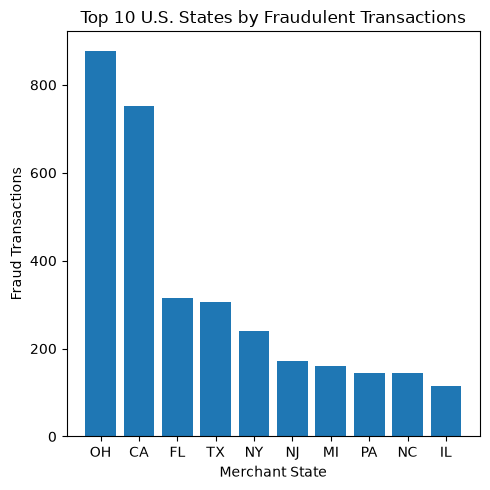

In [35]:
import matplotlib.pyplot as plt

# Collect only the top 10 rows
rows = fraud_by_us_state.limit(10).collect()

states = [row["Merchant State"] for row in rows]
fraud_counts = [row["Fraud Transactions"] for row in rows]

plt.figure(figsize=(5, 5))
plt.bar(states, fraud_counts)

plt.title("Top 10 U.S. States by Fraudulent Transactions")
plt.xlabel("Merchant State")
plt.ylabel("Fraud Transactions")

plt.tight_layout()
plt.show()

# 14.3 – Fraud by International Merchant Location

In [36]:
fraud_by_international_location = (
    enriched_transactions_df
    .filter(F.col("Is Fraud?") == "Yes")
    .filter(F.col("Merchant State").isNotNull())
    .filter(~F.col("Merchant State").isin(us_state_codes))
    .groupBy("Merchant State")
    .agg(
        F.count("*").alias("Fraud Transactions"),
        F.round(F.sum("Amount"), 2).alias("Fraud Amount")
    )
    .orderBy(F.desc("Fraud Transactions"))
)

fraud_by_international_location.show(20, truncate=False)

[Stage 71:====================================================>   (17 + 1) / 18]

+--------------+------------------+------------+
|Merchant State|Fraud Transactions|Fraud Amount|
+--------------+------------------+------------+
|Italy         |4682              |371806.91   |
|Algeria       |629               |78040.13    |
|Haiti         |375               |32175.22    |
|Mexico        |272               |27060.62    |
|Turkey        |257               |32722.29    |
|Nigeria       |143               |15761.43    |
|Tuvalu        |59                |4422.21     |
|Japan         |49                |3046.74     |
|Fiji          |32                |4849.64     |
|India         |5                 |139.1       |
+--------------+------------------+------------+



### Explanation

International merchant locations were analyzed separately to better understand the geographic distribution of fraudulent transactions outside the United States.

The results show that **Italy** recorded the highest number of fraudulent transactions (**4,682**) with a total fraudulent transaction value of **$371,806.91**. Other frequently occurring international merchant locations include **Algeria**, **Haiti**, **Mexico**, and **Turkey**.

These findings indicate that the dataset includes fraudulent transactions from both domestic and international merchants. Separating international locations from U.S. states provides a clearer understanding of global fraud patterns and supports more accurate geographic analysis.

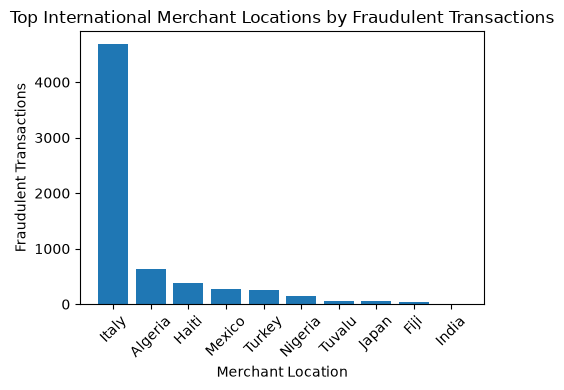

In [37]:
import matplotlib.pyplot as plt

rows = fraud_by_international_location.limit(10).collect()

countries = [row["Merchant State"] for row in rows]
fraud_counts = [row["Fraud Transactions"] for row in rows]

plt.figure(figsize=(5, 4))
plt.bar(countries, fraud_counts)

plt.title("Top International Merchant Locations by Fraudulent Transactions")
plt.xlabel("Merchant Location")
plt.ylabel("Fraudulent Transactions")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 14.4 Average Transaction Amount by Fraud Status

In [38]:
amount_analysis = (
    enriched_transactions_df
    .groupBy("Is Fraud?")
    .agg(
        F.round(F.avg("Amount"), 2).alias("Average Amount"),
        F.round(F.min("Amount"), 2).alias("Minimum Amount"),
        F.round(F.max("Amount"), 2).alias("Maximum Amount"),
        F.count("*").alias("Transaction Count")
    )
)

amount_analysis.show(truncate=False)

[Stage 79:====================================================>   (17 + 1) / 18]

+---------+--------------+--------------+--------------+-----------------+
|Is Fraud?|Average Amount|Minimum Amount|Maximum Amount|Transaction Count|
+---------+--------------+--------------+--------------+-----------------+
|No       |43.55         |-500.0        |12390.5       |24357143         |
|Yes      |108.59        |-500.0        |5694.44       |29757            |
+---------+--------------+--------------+--------------+-----------------+



In [39]:
negative_transactions = (
    enriched_transactions_df
    .filter(F.col("Amount") < 0)
    .groupBy("Is Fraud?")
    .count()
)

negative_transactions.show()

[Stage 83:====================================================>   (17 + 1) / 18]

+---------+-------+
|Is Fraud?|  count|
+---------+-------+
|       No|1243558|
|      Yes|   1125|
+---------+-------+



### Interpretation of Transaction Amounts

Transaction amounts were compared between legitimate and fraudulent transactions to examine whether fraudulent purchases generally involve higher monetary values.

The results show that fraudulent transactions have an average value of **108.59**, compared to **43.55** for legitimate transactions. This indicates that fraudulent purchases are, on average, significantly larger than legitimate purchases.

The largest individual transaction in the dataset (**12,390.50**) was legitimate, while the largest fraudulent transaction was **5,694.44**. Both fraud categories include a minimum transaction amount of **-500.00**.

To better understand these negative values, the dataset was examined for transactions with amounts below zero. The analysis identified **1,243,558** legitimate transactions and **1,125** fraudulent transactions with negative amounts. These transactions likely represent refunds, reversals, credits, or chargebacks rather than standard purchase transactions.

Because these records are part of the original dataset and represent valid financial events, they were retained for the analysis. Overall, the results suggest that transaction amount is an important characteristic for understanding fraud patterns, with fraudulent transactions generally involving higher monetary values than legitimate transactions.

# 14.5 Fraud by Payment Method

In [40]:
payment_method_analysis = (
    enriched_transactions_df
    .filter(F.col("Is Fraud?") == "Yes")
    .groupBy("Use Chip")
    .agg(
        F.count("*").alias("Fraud Transactions"),
        F.round(F.sum("Amount"), 2).alias("Fraud Amount")
    )
    .orderBy(F.desc("Fraud Transactions"))
)

payment_method_analysis.show(truncate=False)

[Stage 87:====================================================>   (17 + 1) / 18]

+------------------+------------------+------------+
|Use Chip          |Fraud Transactions|Fraud Amount|
+------------------+------------------+------------+
|Online Transaction|18349             |2165035.71  |
|Swipe Transaction |6572              |656792.77   |
|Chip Transaction  |4836              |409510.15   |
+------------------+------------------+------------+



### Payment Method Analysis

Fraudulent transactions were grouped by payment method to determine which transaction types were most frequently associated with fraud.

The results show that,
- **Online Transactions** accounted for the highest number of fraudulent transactions (**18,349**) and the largest total fraudulent transaction amount (**$2,165,035.71**). 
- **Swipe Transactions** ranked second with **6,572** fraudulent transactions,
- **Chip Transactions** with **4,836**.

These findings suggest that online transactions are associated with a greater concentration of fraudulent activity than transactions requiring the physical card. Understanding how fraud varies across payment methods can help financial institutions strengthen fraud prevention strategies and prioritize additional security measures for higher-risk transaction types.

# 14.6 Fraud by Merchant Category (MCC)

In [41]:
fraud_by_mcc = (
    enriched_transactions_df
    .filter(F.col("Is Fraud?") == "Yes")
    .groupBy("MCC")
    .agg(
        F.count("*").alias("Fraud Transactions"),
        F.round(F.sum("Amount"), 2).alias("Fraud Amount")
    )
    .orderBy(F.desc("Fraud Transactions"))
)

fraud_by_mcc.show(20, truncate=False)

[Stage 91:====================================================>   (17 + 1) / 18]

+----+------------------+------------+
|MCC |Fraud Transactions|Fraud Amount|
+----+------------------+------------+
|5311|4824              |470315.83   |
|5300|2201              |250295.49   |
|5310|2152              |209978.36   |
|4829|1607              |161206.82   |
|5912|1057              |68418.14    |
|5411|943               |46261.68    |
|5815|879               |46512.23    |
|5651|849               |69669.92    |
|5732|843               |115915.64   |
|5719|717               |71412.13    |
|5094|567               |64044.65    |
|4121|558               |20690.81    |
|5211|475               |39191.44    |
|5045|470               |52607.03    |
|5814|466               |22106.32    |
|5712|418               |124155.73   |
|4722|406               |39764.0     |
|4814|401               |93434.04    |
|5541|354               |12091.54    |
|7922|328               |37739.57    |
+----+------------------+------------+
only showing top 20 rows



### Merchant Category Analysis

Merchant Category Codes (MCCs) were analyzed to identify the types of merchants most frequently associated with fraudulent transactions. An MCC is a standardized four-digit code assigned to merchants based on the goods or services they provide.

The results show that **MCC 5311** recorded the highest number of fraudulent transactions (**4,824**) and the largest total fraudulent transaction amount (**$470,315.83**). Other frequently occurring categories include **5300**, **5310**, and **4829**.

These findings indicate that fraudulent activity is concentrated within specific merchant categories rather than being evenly distributed across all business types. Identifying high-risk merchant categories can help financial institutions focus fraud monitoring and risk management efforts.

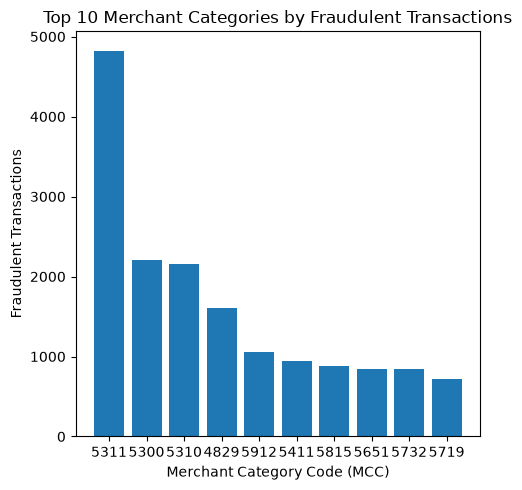

In [42]:
import matplotlib.pyplot as plt

rows = fraud_by_mcc.limit(10).collect()

mcc = [str(row["MCC"]) for row in rows]
fraud_counts = [row["Fraud Transactions"] for row in rows]

plt.figure(figsize=(5, 5))
plt.bar(mcc, fraud_counts)

plt.title("Top 10 Merchant Categories by Fraudulent Transactions")
plt.xlabel("Merchant Category Code (MCC)")
plt.ylabel("Fraudulent Transactions")

plt.tight_layout()
plt.show()

## 14.6.1 Reference: Common Merchant Category Codes (MCC)
### Reference: Common Merchant Category Codes (MCC)

Merchant Category Codes (MCCs) are standardized four-digit codes assigned to merchants based on the primary goods or services they provide. These codes are widely used by financial institutions and payment networks to classify transactions for reporting, risk management, and fraud monitoring.

The table below provides common descriptions for the merchant categories that appeared most frequently in the fraud analysis.

| **MCC** | **Common Merchant Category Description** |
|:-------:|------------------------------------------|
| **5311** | Department Stores |
| **5300** | Wholesale Clubs / Warehouse Stores |
| **5310** | Discount Stores |
| **4829** | Money Transfer / Wire Transfer Services |
| **5912** | Drug Stores / Pharmacies |
| **5411** | Grocery Stores / Supermarkets |
| **5815** | Digital Goods / Media Services |
| **5651** | Family Clothing Stores |
| **5732** | Electronics Stores |
| **5719** | Home Furnishing Specialty Stores |
| **5094** | Precious Stones, Metals, Watches & Jewelry |
| **4121** | Taxi and Limousine Services |
| **5211** | Lumber and Building Materials Stores |
| **5045** | Computers, Computer Equipment and Software |
| **5814** | Fast Food Restaurants |
| **5712** | Furniture Stores |
| **4722** | Travel Agencies and Tour Operators |
| **4814** | Telecommunications Services |
| **5541** | Service Stations / Fuel Stations |
| **7922** | Theatrical Producers and Ticket Agencies |

### Interpretation

The merchant category reference provides context for interpreting the fraud analysis results. Rather than viewing the MCC values as numerical codes, they can be associated with the types of businesses where fraudulent transactions occurred.

The analysis indicates that fraud was observed across a diverse range of merchant categories, including retail stores, online and digital services, money transfer services, grocery stores, travel agencies, telecommunications providers, and fuel stations. This suggests that fraudulent activity is not limited to a single industry but spans multiple sectors of the retail and service economy.

Understanding the business categories associated with fraud helps financial institutions identify higher-risk transaction types and develop targeted fraud detection and prevention strategies.

# 14.7 Fraud by ZIP Code (Geospatial Analysis)

In [43]:
fraud_by_zip = (
    enriched_transactions_df
    .filter(F.col("Is Fraud?") == "Yes")
    .filter(F.col("Zip").isNotNull())
    .groupBy("Zip")
    .agg(
        F.count("*").alias("Fraud Transactions"),
        F.round(F.sum("Amount"), 2).alias("Fraud Amount"),
        F.first("INTPTLAT").alias("Latitude"),
        F.first("INTPTLONG").alias("Longitude")
    )
    .orderBy(F.desc("Fraud Transactions"))
)

fraud_by_zip.show(20, truncate=False)

[Stage 99:====================================================>   (17 + 1) / 18]

+-----+------------------+------------+---------+-----------+
|Zip  |Fraud Transactions|Fraud Amount|Latitude |Longitude  |
+-----+------------------+------------+---------+-----------+
|44680|320               |41232.36    |40.598967|-81.544039 |
|44807|58                |6237.49     |41.061226|-82.864336 |
|44811|56                |7089.91     |41.246317|-82.846599 |
|44820|48                |4928.96     |40.818352|-82.971722 |
|94606|45                |5459.63     |37.791366|-122.244513|
|94702|40                |6330.64     |37.866321|-122.286348|
|44681|38                |7065.58     |40.500822|-81.663619 |
|44824|25                |2883.88     |41.383272|-82.805888 |
|45014|22                |2578.3      |39.325714|-84.55239  |
|94662|21                |2195.71     |NULL     |NULL       |
|44842|20                |2119.41     |40.649212|-82.224849 |
|94804|18                |1981.38     |37.915463|-122.337815|
|44836|18                |979.73      |41.237162|-83.062895 |
|89148|1

### ZIP Code Analysis

The enriched transaction dataset was grouped by ZIP Code to identify geographic areas with the highest number of fraudulent transactions. By integrating the IBM transaction data with the Census ZCTA dataset, each ZIP Code was linked to geographic coordinates whenever available.

The results show that **ZIP Code 44680** recorded the highest number of fraudulent transactions (**320**) with a total fraudulent transaction amount of **$41,232.36**. Other ZIP Codes with elevated fraud activity include **44807**, **44811**, **44820**, and **94606**.

Most ZIP Codes were successfully enriched with latitude and longitude, enabling future geographic visualization and spatial analysis. A small number of ZIP Codes contained missing geographic coordinates, indicating that a matching Census record was unavailable.

Overall, the integration of transaction and geographic data provides a more detailed understanding of where fraudulent activity is concentrated and supports location-based fraud monitoring.

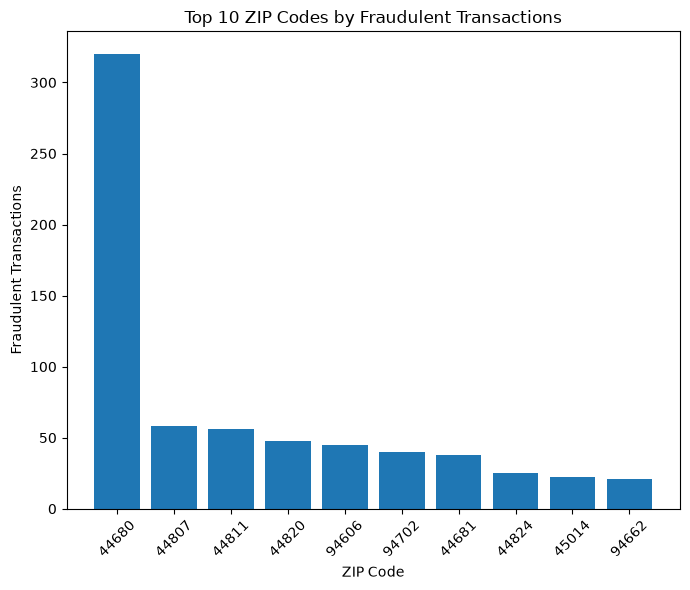

In [46]:
import matplotlib.pyplot as plt

rows = fraud_by_zip.limit(10).collect()

zip_codes = [row["Zip"] for row in rows]
fraud_counts = [row["Fraud Transactions"] for row in rows]

plt.figure(figsize=(7,6))
plt.bar(zip_codes, fraud_counts)

plt.title("Top 10 ZIP Codes by Fraudulent Transactions")
plt.xlabel("ZIP Code")
plt.ylabel("Fraudulent Transactions")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 14.8 Geographic Coverage

In [45]:
geo_summary = (
    enriched_transactions_df
    .filter(F.col("INTPTLAT").isNotNull())
    .agg(
        F.count("*").alias("Transactions with Geographic Coordinates")
    )
)

geo_summary.show()

[Stage 107:===================================================>   (17 + 1) / 18]

+----------------------------------------+
|Transactions with Geographic Coordinates|
+----------------------------------------+
|                                21221404|
+----------------------------------------+



### Geographic Coverage

Following the data integration process, transaction records were enriched with geographic coordinates by joining the IBM Credit Card Transactions dataset with the U.S. Census ZCTA dataset.

A total of **21,221,404** transactions were successfully matched with latitude and longitude information, representing approximately **87.02%** of the entire dataset. This high match rate demonstrates the effectiveness of the geographic enrichment process and provides a strong foundation for location-based fraud analysis.

The availability of geographic coordinates enables future spatial analyses, including fraud hotspot mapping, regional risk assessment, and geographic visualization of fraudulent transaction patterns.

# 15. Key Findings

The exploratory analysis produced several important insights into fraudulent credit card transactions and demonstrated the value of integrating transaction data with external geographic information.

- The dataset contains **24,386,900** credit card transactions, including **29,757** fraudulent transactions, resulting in an overall fraud rate of **0.1220%**.

- Data integration with the U.S. Census ZCTA dataset successfully enriched **21,221,404** transactions (**87.02%**) with geographic coordinates, enabling location-based fraud analysis.

- Fraudulent activity was concentrated in specific U.S. states, with **Ohio** recording the highest number of fraudulent transactions among domestic merchant locations.

- Among international merchant locations, **Italy** recorded the highest number of fraudulent transactions in the dataset.

- Fraudulent transactions had a substantially higher average transaction amount (**$108.59**) than legitimate transactions (**$43.55**), indicating that fraudulent purchases generally involved larger monetary values.

- **Online transactions** accounted for the largest share of fraudulent activity, followed by swipe and chip transactions.

- Fraud was concentrated within specific merchant categories (MCCs), suggesting that certain business sectors experience higher levels of fraudulent activity than others.

- Geographic analysis at the ZIP Code level identified several areas with elevated fraud activity, demonstrating how spatial information can provide additional insight beyond traditional transaction analysis.

# 16. Conclusion

This project developed a scalable fraud analytics workflow using Apache Spark to analyze more than **24 million** credit card transactions. The project followed the CRISP-DM methodology, including data understanding, preparation, integration, exploratory analysis, and interpretation of results.

By integrating the IBM Credit Card Transactions dataset with the U.S. Census ZCTA dataset, the project successfully enriched transaction records with geographic information, allowing fraud to be analyzed from both transactional and spatial perspectives. The analysis identified important fraud patterns across payment methods, merchant categories, geographic regions, transaction amounts, and ZIP Codes.

The use of Apache Spark enabled efficient processing of a large-scale dataset while demonstrating distributed data processing techniques suitable for big data applications. The geographic enrichment further illustrated how external datasets can improve the analytical value of financial transaction data.

One limitation of the project is that some transactions could not be geographically enriched because of missing or unmatched ZIP Codes. Additionally, this project focused on descriptive analytics rather than predictive fraud detection.

Future work could extend this project by developing machine learning models for fraud prediction, implementing real-time fraud detection using streaming data, and creating interactive geographic dashboards for fraud hotspot visualization.

# 17. References

1. IBM. *Synthetic Financial Datasets for Fraud Detection*. Kaggle. https://www.kaggle.com/datasets/ealtman2019/credit-card-transactions

2. United States Census Bureau. *ZIP Code Tabulation Areas (ZCTA) Gazetteer Files*. https://www.census.gov/geographies/reference-files/time-series/geo/gazetteer-files.html

3. Apache Software Foundation. *Apache Spark Documentation*. https://spark.apache.org/docs/latest/

4. Han, J., Kamber, M., & Pei, J. (2012). *Data Mining: Concepts and Techniques* (3rd ed.). Morgan Kaufmann.